# Check age proportions in SSNAP data

Check the derived age-admissions coefficients by using them to recalculate the admissions numbers.

__Inputs:__
+ coefficients for "probability of stroke given age band" derived from the SSNAP data.
+ MSOA-level deprivation quantile and number of people in each age band.

__Results:__
+ Image: calculated vs. observed admission numbers for all MSOA
+ Image: calculated vs. observed admission numbers for all MSOA, split into one panel per deprivation band.


## Code setup

In [29]:
import polars as pl
import os
import numpy as np
import matplotlib.pyplot as plt

## Load data

HES data:

In [30]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

## Load SSNAP-derived probability coefficients:

In [31]:
df_pop_admissions = pl.read_csv(os.path.join('outputs', 'ssnap_coeffs.csv'))

## Check results: recalculate admissions

Calculate from SSNAP coefficients:

In [32]:
admission_props_annual = df_pop_admissions['prob_stroke_given_age'].to_numpy()

admission_props_annual

array([0.000408, 0.002644, 0.003735, 0.006005, 0.011558])

In [33]:
admissions_snap_props = sum([
    admission_props_annual[0] * df_stats['age_less65'],
    admission_props_annual[1] * df_stats['age_65'],
    admission_props_annual[2] * df_stats['age_70'],
    admission_props_annual[3] * df_stats['age_75'],
    admission_props_annual[4] * df_stats['age_over80'],
])
df_stats = df_stats.with_columns(pl.Series('admissions_from_ssnap_props', admissions_snap_props))

In [34]:
df_stats['admissions', 'admissions_from_ssnap_props']

admissions,admissions_from_ssnap_props
f64,f64
14.333333,14.423034
7.333333,13.377178
9.333333,12.579268
21.0,16.660679
13.666667,15.765181
…,…
14.333333,13.032092
12.666667,11.970012
16.333333,16.405731


## R-squared

Calculate r-squared metric:

In [35]:
def calculate_rsquared(y, yhat):
    """This gives the same results as the sklearn built-in."""
    y_mean = y.mean()
    ss_res = ((yhat - y)**2.0).sum()
    ss_tot = ((y - y_mean)**2.0).sum()
    if ss_tot != 0.0:
        rsq = 1.0 - ss_res / ss_tot
    else:
        rsq = np.NaN
    return rsq

In [36]:
qmin_list = sorted(df_stats['depriv_quantile_min'].unique())
qmax_list = sorted(df_stats['depriv_quantile_max'].unique())

In [37]:
dict_r2 = {}

# R-squared for all points:
dict_r2['r2_all'] = np.round(calculate_rsquared(df_stats['admissions'], df_stats['admissions_from_ssnap_props']), 5)

# Separate r-squared for each deprivation quantile:
for q in qmin_list:
    qstr = str(round(q, 1)).replace('.', '')
    df_here = df_stats.filter(df_stats['depriv_quantile_min'] == q)

    r2_q = calculate_rsquared(df_here['admissions'], df_here['admissions_from_ssnap_props'])
    dict_r2[f'r2_q{qstr}'] = np.round(r2_q, 5)

In [38]:
dict_r2

{'r2_all': 0.47253,
 'r2_q00': 0.17179,
 'r2_q02': 0.52766,
 'r2_q04': 0.63211,
 'r2_q06': 0.55682,
 'r2_q08': 0.41202}

### Scatter results

In [50]:
# dict_labels = dict(zip(qmin_list, ['0% to 20% (most deprived)', '20% to 40%', '40% to 60%', '60% to 80%', '80% to 100% (least deprived)']))
# labels = ['0-20% (most deprived)', '20-40%', '40-60%', '60-80%', '80-100% (least deprived)']
labels = []
for q, qmin in enumerate(qmin_list):
    label = f'{100.0*qmin:.0f}-{100.0*qmax_list[q]:.0f}%'
    labels.append(label)
labels[0] += ' (most deprived)'
labels[-1] += ' (least deprived)'
dict_labels = dict(zip(qmin_list, labels))

In [40]:
zmax = max([df_stats['admissions'].max(), max(df_stats['admissions_from_ssnap_props'])])
zmin = min([df_stats['admissions'].min(), min(df_stats['admissions_from_ssnap_props'])])

colours = plt.get_cmap('viridis')(np.linspace(0.0, 1.0, len(qmin_list)))

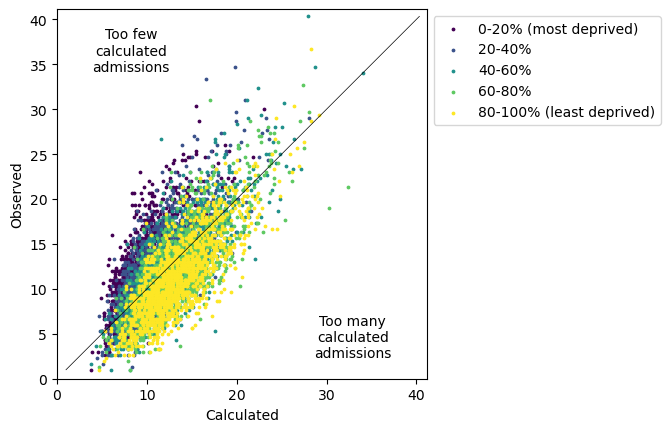

In [51]:
fig, ax = plt.subplots()
# Equality line:
ax.plot([zmin, zmax], [zmin, zmax], color='k', linewidth=0.5)

# Draw each quantile's data in turn:
for q, qmin in enumerate(qmin_list):
    df_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    ax.scatter(df_here['admissions_from_ssnap_props'], df_here['admissions'], s=3, color=colours[q], label=dict_labels[qmin])

# Labels:
ax.set_ylabel('Observed')
ax.set_xlabel('Calculated')
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
# Annotate which parts of the graph mean too high/low admissions:
ax.annotate('Too few\ncalculated\nadmissions', xy=(0.2, 0.95), ha='center', va='top', xycoords='axes fraction')
ax.annotate('Too many\ncalculated\nadmissions', xy=(0.8, 0.05), ha='center', va='bottom', xycoords='axes fraction')
# Sizing:
ax.set_xlim(0.0, zmax*1.02)
ax.set_ylim(0.0, zmax*1.02)
ax.set_aspect('equal')
# Save:
plt.savefig('./images/scatter_admissions_from_ssnap_coeffs.png', bbox_inches='tight')
plt.show()

Admissions are under-predicted for lowest quantile (most deprived) and over-predicted for highest quantile (least deprived).

Make a similar figure with the same data but each deprivation quantile on its own axis:

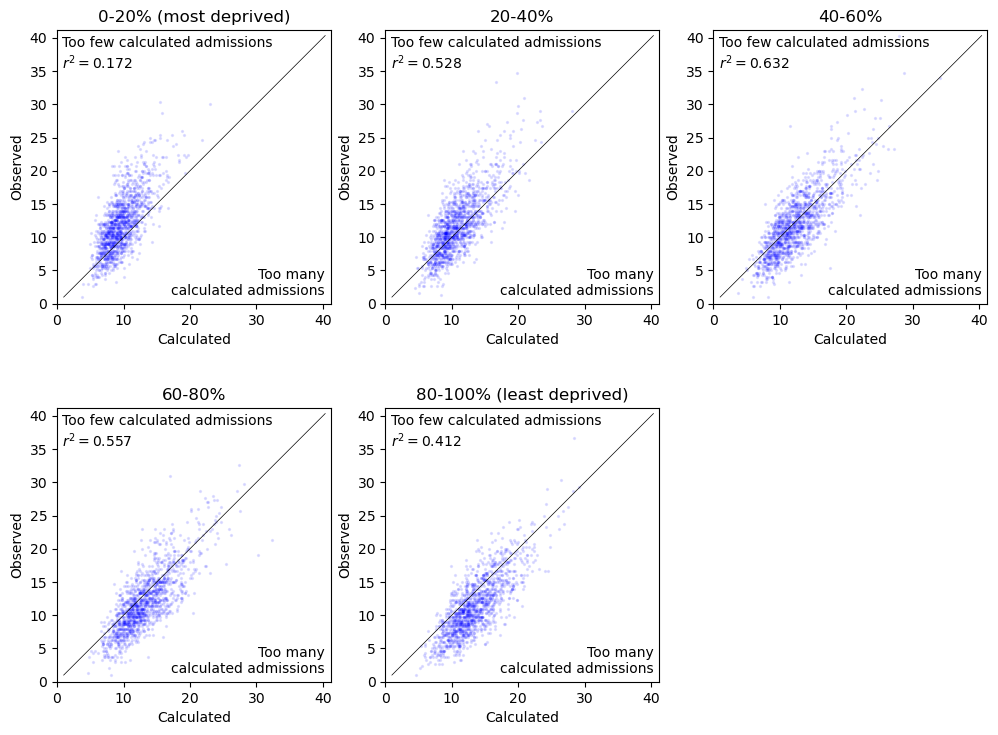

In [52]:
ncols=3
nrows=2
fig, axs = plt.subplots(nrows, ncols, figsize=(12, 9))

# Draw each quantile's data in turn:
for q, qmin in enumerate(qmin_list):
    ax = axs[q // ncols, q % ncols]
    # Equality line:
    ax.plot([zmin, zmax], [zmin, zmax], color='k', linewidth=0.5)
    
    df_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    ax.scatter(
        df_here['admissions_from_ssnap_props'],
        df_here['admissions'],
        s=2,
        # color=colours[q],
        color='b',
        alpha=0.1
    )
    
    # Labels:
    ax.set_ylabel('Observed')
    ax.set_xlabel('Calculated')
    ax.set_title(dict_labels[qmin])
    # Annotate r-squared value:
    r2_key = f'r2_q{qmin:.1f}'.replace('.', '')
    r_str = r'$r^2=$' + f"{dict_r2[r2_key]:.3f}"
    # ax.annotate(, xy=(0.05, 0.85), ha='left', va='top', xycoords='axes fraction')
    # Annotate which parts of the graph mean too high/low admissions:
    ax.annotate('Too few calculated admissions\n'+r_str, xy=(0.02, 0.98), ha='left', va='top', xycoords='axes fraction')
    ax.annotate('Too many\ncalculated admissions', xy=(0.98, 0.02), ha='right', va='bottom', xycoords='axes fraction')
    # Sizing:
    ax.set_xlim(0.0, zmax*1.02)
    ax.set_ylim(0.0, zmax*1.02)
    ax.set_aspect('equal')

axs[-1, -1].set_visible(False)
# Save:
plt.savefig('./images/scatter_admissions_from_ssnap_coeffs_separate.png', bbox_inches='tight')
plt.show()

In [43]:
dict_labels_1row = {}

for key, val in dict_labels.items():
    dict_labels_1row[key] = val.replace('(', '\n(')

In [44]:
import matplotlib.ticker  # for axis tick location

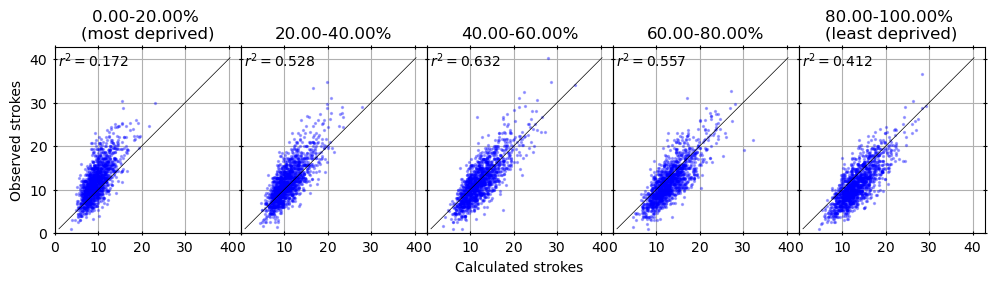

In [54]:
ncols=5
nrows=1
fig, axs = plt.subplots(nrows, ncols, figsize=(12, 5), sharey=True, sharex=True, gridspec_kw={'wspace': 0.0, 'hspace':0.3})

# Draw each quantile's data in turn:
for q, qmin in enumerate(qmin_list):
    ax = axs[q]
    # ax = axs[q // ncols, q % ncols]
    # Equality line:
    ax.plot([zmin, zmax], [zmin, zmax], color='k', linewidth=0.5, zorder=6)
    
    df_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    ax.scatter(
        df_here['admissions_from_ssnap_props'],
        df_here['admissions'],
        s=2,
        # color=colours[q],
        color='b',
        alpha=0.3,
        zorder=5
    )
    
    # Labels:
    if q == 0:
        ax.set_ylabel('Observed strokes')
    if q == 2:
        ax.set_xlabel('Calculated strokes')
    ax.set_title(dict_labels_1row[qmin])
    # Annotate r-squared value:
    r2_key = f'r2_q{qmin:.1f}'.replace('.', '')
    r_str = r'$r^2=$' + f"{dict_r2[r2_key]:.3f}"
    # ax.annotate(, xy=(0.05, 0.85), ha='left', va='top', xycoords='axes fraction')
    # Annotate which parts of the graph mean too high/low admissions:
    # ax.annotate('Too few calculated admissions\n'+r_str, xy=(0.02, 0.98), ha='left', va='top', xycoords='axes fraction')
    ax.annotate(r_str, xy=(0.02, 0.98), ha='left', va='top', xycoords='axes fraction')
    # ax.annotate('Too many\ncalculated admissions', xy=(0.98, 0.02), ha='right', va='bottom', xycoords='axes fraction')
    # Sizing:
    ax.set_xlim(0.0, zmax*1.06)
    ax.set_ylim(0.0, zmax*1.06)
    ax.set_aspect('equal')
    
    ax.tick_params(direction='inout', axis='both', top=True, right=True)
    ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(10))
    ax.yaxis.set_major_locator(matplotlib.ticker.MultipleLocator(10))
    ax.grid('on')

# Save:
plt.savefig('./images/scatter_admissions_from_ssnap_coeffs_separate_1row.png', bbox_inches='tight')
plt.show()

## Slice bins

Set up the bins. Make them so that values will be grouped to their nearest whole number, e.g. the 13 bin will contain MSOA with predicted admissions numbers from 12.5 (inclusive) to 13.5 (exclusive) admissions.

In [57]:
df = df_stats.filter(df_stats['depriv_quantile_min'] == 0.4)#44)

observed_all = df['admissions']
predicted_all = df['admissions_from_ssnap_props']

In [58]:
# Set up bins with left/right edges between every whole number,
# so the bin middle values are all whole numbers from 0 to
# the number required so that every MSOA has a home:
bins = np.arange(-0.5, np.ceil(max(predicted_all))+0.5, 1.0)
bin_mids = bins + 0.5

# View bins:
bins

array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5,
       10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5,
       21.5, 22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5,
       32.5, 33.5, 34.5])

Use `digitize` to work out which bin each MSOA belongs to. Then make separate lists for each bin to group the MSOA data. Make a list for each group of MSOA's predicted and observed admissions numbers.

In [59]:
# Find which bin each value of predicted admissions belongs in.
# The index of each selected bin (its position in the list) is stored
# in bin_inds.
bin_inds = np.digitize(predicted_all, bins)
# In this list, bin index 0 will be for under -0.5 admissions (which
# shouldn't happen here!). Bin index 1 is for -0.5 (inclusive) to +0.5
# (exclusive).

# Store results as dict of lists:
binned_admissions = {}
binned_predictions = {}
# For each bin in turn, gather the values that belong in it.
for b, bin_left in enumerate(bins):
    # What is the middle of this bin?
    bin_mid = bin_mids[b]
    # Which items in the lists belong in this bin?
    # Add 1 because the first bin (when b=0) is labelled with
    # index 1 in bin_inds.
    p = np.where(bin_inds == b+1)
    # Pick out those items into their own separate list
    # and add them to the dictionary:
    binned_admissions[bin_mid] = np.array(observed_all)[p]
    binned_predictions[bin_mid] = np.array(predicted_all)[p]

Calculate useful statistics for each group. Find its mean, standard deviation, and the number of MSOA in the group.

In [60]:
# Place the results in this dictionary:
dict_stats = dict(
    bin_mids = [],
    means = [],
    stds = [],
    variances = [],
    lengths = [],
)
# Calculate stats and place in the dictionary:
for bin_mid, admissions in binned_admissions.items():
    dict_stats['bin_mids'].append(bin_mid)
    dict_stats['means'].append(np.mean(admissions))
    dict_stats['stds'].append(np.std(admissions))
    dict_stats['variances'].append(np.std(admissions)**2.0)
    dict_stats['lengths'].append(len(admissions))

# Convert the dictionary to a DataFrame:
df_bin_stats = pl.DataFrame()
for col, vals in dict_stats.items():
    df_bin_stats = df_bin_stats.with_columns(pl.Series(col, vals))

/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/anna/miniconda3/envs/stroke_lsoa_prediction/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  

In [61]:

from scipy.stats import norm  # for normal distribution

1.41 1.74 2.45
1.53 1.85 2.65
1.63 2.23 2.83
1.73 2.48 3.00
1.83 2.53 3.16
1.91 2.48 3.32
2.00 3.17 3.46
2.08 2.91 3.61
2.16 2.99 3.74
2.24 2.68 3.87
2.31 3.06 4.00
2.38 3.43 4.12
2.45 4.34 4.24
2.52 3.23 4.36
2.58 3.40 4.47
2.65 4.44 4.58
2.71 4.80 4.69
2.77 3.70 4.80
2.83 2.68 4.90
2.89 4.19 5.00


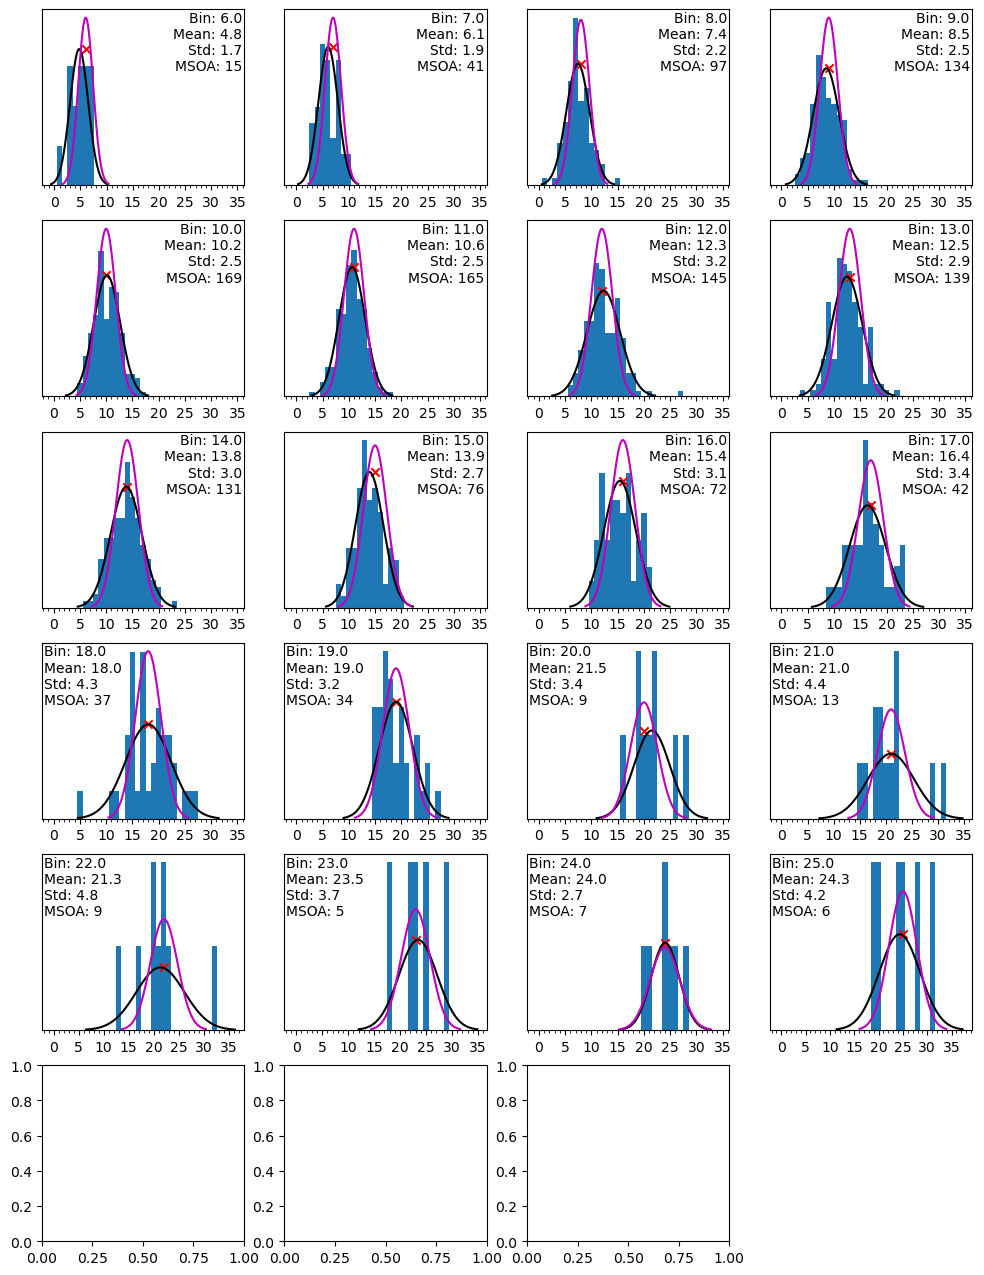

In [62]:
fig, axs = plt.subplots(6, 4, figsize=(12, 16))

# Only use bins that contain at least 5 MSOA:
df = df_bin_stats.filter(df_bin_stats['lengths'] >= 5)
# Plot each bin in turn:
for i in range(len(df)):
    # Select next available axis:
    ax = axs[i // 4, i % 4,]
    # Pick out data:
    b = df['bin_mids'][i]
    mean = df['means'][i]
    std = df['stds'][i]
    loc = b
    # scale = std
    scale = np.sqrt(loc / 3.0)
    print(f'{scale:.2f} {std:.2f} {np.sqrt(loc):.2f}')
    admissions_here = binned_admissions[b]


    # Create normal distribution coordinates:
    norm_x = np.linspace(norm.ppf(0.001, loc=mean, scale=std),
                         norm.ppf(0.999, loc=mean, scale=std), 100)
    norm_y = norm.pdf(norm_x, loc=mean, scale=std)
    # Create second dist from expected std:
    norm_x2 = np.linspace(norm.ppf(0.001, loc=loc, scale=scale),
                         norm.ppf(0.999, loc=loc, scale=scale), 100)
    norm_y2 = norm.pdf(norm_x2, loc=loc, scale=scale)
    # norm_x = np.linspace(norm.ppf(0.001, loc=loc, scale=np.sqrt(loc)),
    #                      norm.ppf(0.999, loc=loc, scale=np.sqrt(loc)), 100)
    # norm_y = norm.pdf(norm_x, loc=loc, scale=np.sqrt(loc))

    # Bar chart:
    ax.hist(admissions_here, bins=bins, density=True, label='Observed strokes')
    # Mark expected mean:
    ax.scatter(b, max(norm_y), marker='x', color='r', linestyle='-', label='Predicted strokes')
    # # Mark one standard deviation from the mean:
    # ax.axvline(loc, color='k', linestyle='--', label='Mean')
    # ax.axvline(loc + scale, color='k', linestyle=':', label=r'Mean $\pm$ 1 std')
    # ax.axvline(loc - scale, color='k', linestyle=':', label=None)
    # Normal dist:
    ax.plot(norm_x, norm_y, color='k', label='Normal distribution')
    ax.plot(norm_x2, norm_y2, color='m', label='Poisson distribution')

    # Remove y ticks and labels.
    ax.set_yticks([])
    # Mark bin edges:
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
    ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(5))

    # Label each plot with the mean and std of the normal dist
    # as well as how many MSOA are in the bin.
    label = f'Bin: {b}' + '\n' + f'Mean: {mean:.1f}' + '\n' + f'Std: {std:.1f}' + '\n' + f'MSOA: {df["lengths"][i]}'
    # Draw the label on either the top left or the top right
    # depending on where there's room:
    if i < 12:
        ax.annotate(label, xy=(0.99, 0.99), va='top', ha='right', xycoords='axes fraction')
    else:
        ax.annotate(label, xy=(0.01, 0.99), va='top', ha='left', xycoords='axes fraction')
    
    # If this is the last graph then draw the legend in the
    # gap left by the empty axis.
    if i == 22:
        ax.legend(loc='center left', bbox_to_anchor=[1.0, 0.5])

# Remove the unwanted final axis:
axs[-1, -1].set_visible(False)

# plt.savefig(os.path.join('images', 'uncertainty_observed_admissions_variance.png'), bbox_inches='tight', dpi=200)
plt.show()